In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from matplotlib import colors
from matplotlib.colors import LogNorm

from pathlib import Path
from datetime import datetime
from io import StringIO

import subprocess
import tempfile
import os

working_dir = '/Users/jakobwerkgarner/code/mt_dsnow'
os.chdir(working_dir)

# Create Validation Data

In [2]:
# === Define paths ===
src = Path("calibration/calibration_data/raw_data/Mag25/SLF_dataset/Mag25_all.nc")
dst = Path("HNW_validation/validation_input")
dst.mkdir(parents=True, exist_ok=True)

# === Load dataset ===
ds = xr.open_dataset(src)

# Rename time → date
ds = ds.rename({"time": "date"})

# === Seasons (2016–2022) ===
seasons = [f"{y:02d}{(y+1)%100:02d}" for y in range(16, 22)]
for s in seasons:
    (dst / s).mkdir(parents=True, exist_ok=True)

# === Assign season per date ===
def get_season(ts):
    m, y = ts.month, ts.year
    if m in (11, 12):
        return f"{y % 100:02d}{(y+1) % 100:02d}"
    elif m in (1, 2, 3, 4):
        return f"{(y-1) % 100:02d}{y % 100:02d}"
    return None

dates = pd.to_datetime(ds.date.values)
ds = ds.assign_coords(season=("date", [get_season(t) for t in dates]))

ds = ds.where(ds.season.isin(seasons), drop=True)

# === Loop station × season ===
summary = []

for station in ds.station.values:
    ds_station = ds.sel(station=station)

    for s in seasons:
        sub = ds_station.where(ds_station.season == s, drop=True)

        if sub.date.size == 0:
            summary.append((station, s, 0))
            continue

        df = sub.to_dataframe().reset_index()
        df = df.drop(columns=["station", "season"])
        df["date"] = pd.to_datetime(df["date"]).dt.strftime("%Y-%m-%d")

        df.at[df.index[0], "hs"] = 0

        out_file = dst / s / f"{station}.csv"
        df.to_csv(out_file, index=False)

        summary.append((station, s, len(df)))

summary_df = pd.DataFrame(summary, columns=["station", "season", "rows"])
summary_df.to_csv(dst / "season_station_summary.csv", index=False)

# ΔSNOW Model Runner Configuration

In [16]:
PARAMS = {
    "rho.max": 451.6977806582531,
    "rho.null": 90.0,
    "c.ov": 2.746976858091589e-0,
    "k.ov": 0.38,
    "k": 0.020385468323087456,
    "tau":  0.001,
    "eta.null": 8.5e6
}




DATA_DIR = Path("HNW_validation/validation_input")

OUT_DIR = Path('HNW_validation/validation_output')
OUT_DIR.mkdir(parents=True, exist_ok=True)

R_BIN = "/usr/local/bin/Rscript"
R_RUNNER = "calibration/helpers/minimal_delta_snow_runner.R"

YEARS = [1617, 
         1718, 
         1819, 
         1920, 
         2021, 
         2122]

STATIONS = [
    "Adelboden", "Gadmen", "Grindelwald_Bort", "Gsteig", "Gantrisch",
    "Leysin", "Muerren", "Saanenmoeser", "Wengen", "Sorenberg", "Stoos",
    "Braunwald", "Malbun", "St_Margrethenberg", "Binn", "Bourg_St_Pierre",
    "Fionnay", "Grimentz", "Lauchernalp", "Montana", "Muenster",
    "Saas_Fee", "Simplon_Dorf", "Ulrichen", "Wiler", "Bivio",
    "Davos_Flueelastr", "Juf", "Obersaxen", "Pusserein", "St_Antoenien",
    "Sedrun", "Spluegen", "Vals", "Weisfluh_Joch", "Bosco_Gurin",
    "San_Bernadino", "Maloja", "Sankt_Moritz", "Samnaun", "Zuoz"
]


## Helpers

In [17]:
def run_r_model(csv_path):

    df = pd.read_csv(csv_path)

    if "HS" in df.columns:
        hs_col = "HS"
    elif "HS_obs" in df.columns:
        hs_col = "HS_obs"
    else:
        raise ValueError("Missing HS column")

    df_r = pd.DataFrame({
        "date": df["date"],
        "hs": df[hs_col]
    })

    df_r.at[df_r.index[0], "hs"] = 0

    with tempfile.NamedTemporaryFile(delete=False, suffix=".csv") as tmp:
        tmp_path = Path(tmp.name)
        df_r.to_csv(tmp_path, index=False)

    cmd = [R_BIN, R_RUNNER, "--in", str(tmp_path)]
    for k, v in PARAMS.items():
        cmd += [f"--{k}", str(v)]

    proc = subprocess.run(cmd, capture_output=True, text=True)

    os.remove(tmp_path)

    if proc.returncode != 0:
        print(proc.stdout)
        print(proc.stderr)
        raise RuntimeError("R model failed")

    df_out = pd.read_csv(StringIO(proc.stdout))
    df_out["date"] = pd.to_datetime(df_out["date"]).dt.strftime("%Y-%m-%d")

    return df_out.rename(columns={"hs": "hs_mod", "swe_mod": "SWE_mod"})


def load_input(csv_path):
    df = pd.read_csv(csv_path)
    df["date"] = pd.to_datetime(df["date"]).dt.strftime("%Y-%m-%d")
    df = df.rename(columns={"HS": "HS_obs", "HNW": "HNW_obs"})
    return df

# Run Model for All Stations & Seasons

In [18]:
all_rows = []


n_stations = len(STATIONS)

it_count = 0


for station in STATIONS:

    it_count = it_count + 1
    
    print(f"Processing Staion number {it_count}/{n_stations} called {station}")
    station_rows = []

    for yr in YEARS:
        in_csv = DATA_DIR / str(yr) / f"{station}.csv"

        if not in_csv.exists():
            print(f"[SKIP] Missing {in_csv}")
            continue

        print(f"[RUN] {station} {yr}")

        df_in = load_input(in_csv)
        df_r = run_r_model(in_csv)

        merged = df_in.merge(df_r, on="date", how="left")

        merged["HNW_mod"] = merged["SWE_mod"].diff()

        merged["station"] = station
        merged["season"] = yr


        station_rows.append(merged)
        all_rows.append(merged)

    if station_rows:
        st_all = pd.concat(station_rows, ignore_index=True)
        st_all.to_csv(OUT_DIR / f"{station}_all_seasons.csv", index=False)

# Merge all stations
all_df = pd.concat(all_rows, ignore_index=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
all_df.to_csv(OUT_DIR / f"{timestamp}_ALL_STATIONS_ALL_YEARS.csv", index=False)

print("Saved merged dataset.")

Processing Staion number 1/41 called Adelboden
[RUN] Adelboden 1617
[RUN] Adelboden 1718
[RUN] Adelboden 1819

Error in if (all(rho.max - swe.d[1:ly]/h.d[1:ly] <= prec)) { : 
  missing value where TRUE/FALSE needed
Calls: swe.delta.snow -> drenchH
In addition: Warning messages:
1: In scaleH(t, ly, ly.tot, day.tot, deltaH, Hobs, h, swe, age, H,  :
  day 61: error in exponential re-compaction: H.dd.cor-Hobs.dd=4.98436979190497e-10
2: In scaleH(t, ly, ly.tot, day.tot, deltaH, Hobs, h, swe, age, H,  :
  day 62: error in exponential re-compaction: H.dd.cor-Hobs.dd=4.98436979190497e-10
Execution halted



RuntimeError: R model failed

# SWE Validation Plot (single clean version)

In [10]:
#all_df = pd.read_csv('HNW_validation/validation_output/20251203_1106_ALL_STATIONS_ALL_YEARS.csv')

load if already exits

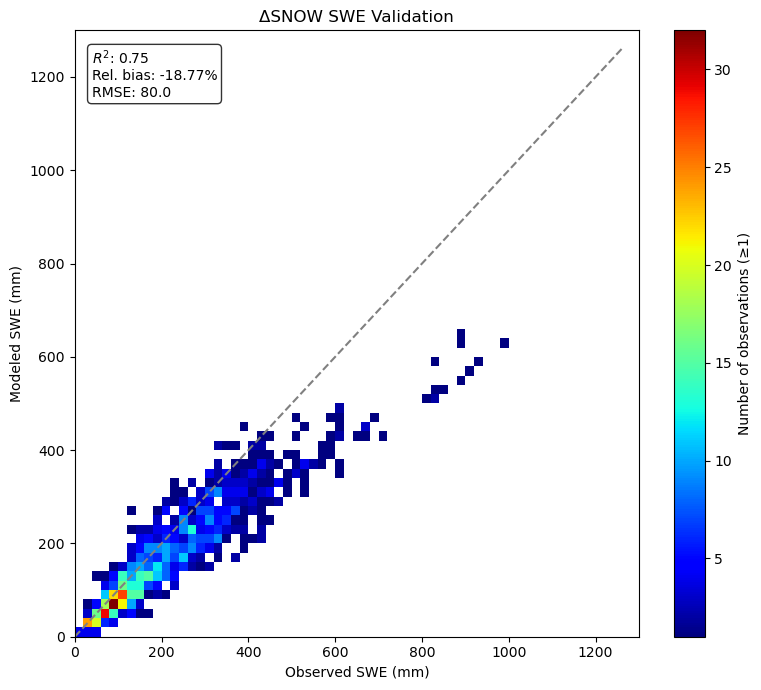

In [11]:
# SWE VALIDATION
df_valid = all_df[
    all_df["SWE"].notna() &
    all_df["SWE_mod"].notna() &
    (all_df["SWE"] > 0) &
    (all_df["SWE_mod"] > 0)
]

x = df_valid["SWE"].values
y = df_valid["SWE_mod"].values

residuals = y - x
rmse = np.sqrt(np.mean(residuals**2))
pbias = 100 * np.sum(residuals) / np.sum(x)

# R² calculation
ss_res = np.sum((x - y)**2)
ss_tot = np.sum((x - np.mean(x))**2)
r2 = 1 - ss_res / ss_tot

bins = 50
range_x = range_y = [0, 1000]

counts, xedges, yedges = np.histogram2d(x, y, bins=bins, range=[range_x, range_y])
counts[counts == 0] = np.nan

cmap = plt.get_cmap("jet").copy()
cmap.set_bad("white")

plt.figure(figsize=(8, 7))
plt.pcolormesh(xedges, yedges, counts.T, cmap=cmap, shading="auto")
plt.colorbar(label="Number of observations (≥1)")

lim = [0, max(x.max(), y.max()) * 1.05]
plt.plot(lim, lim, "--", color="gray")

plt.xlabel("Observed SWE (mm)")
plt.ylabel("Modeled SWE (mm)")
plt.title("ΔSNOW SWE Validation")

plt.text(0.03, 0.97,
         f"$R^2$: {r2:.2f}\nRel. bias: {pbias:.2f}%\nRMSE: {rmse:.1f}",
         transform=plt.gca().transAxes,
         va="top",
         bbox=dict(boxstyle="round", fc="white", alpha=0.8))

plt.xlim((0, 1300))
plt.ylim((0, 1300))
plt.tight_layout()
plt.show()

# HNW Validation Plot

N        = 35346
RMSE     = 7.450
Bias     = -2.213
PBIAS    = -102.87%
R²       = -0.036


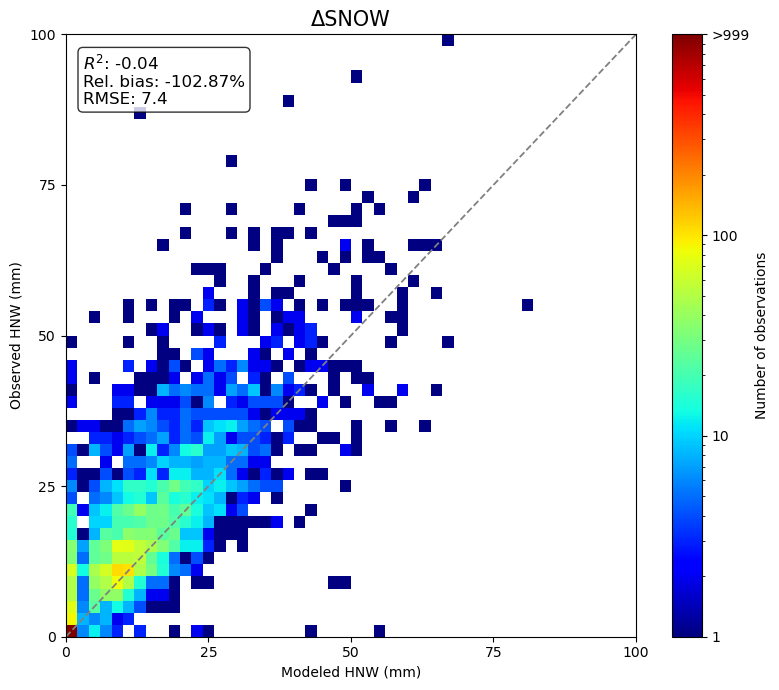

In [12]:
# ---------------------------------------------------------
# HNW VALIDATION
# ---------------------------------------------------------

# Keep only rows with valid modeled + observed HNW values
df_valid = all_df.dropna(subset=["HNW_obs", "HNW_mod"])
df_valid = df_valid[df_valid["HNW_obs"] >= 0]


# Safety filter for non-finite values
df_valid = df_valid[
    np.isfinite(df_valid["HNW_obs"]) &
    np.isfinite(df_valid["HNW_mod"])
]

# Observed + modeled
y = df_valid["HNW_obs"].values   # observed
x = df_valid["HNW_mod"].values   # modeled

# ---------------------------------------------------------
# METRICS (NO REGRESSION)
# ---------------------------------------------------------
residuals = x - y

rmse = np.sqrt(np.mean(residuals**2))
bias = np.mean(residuals)
pbias = 100 * np.sum(residuals) / np.sum(y)

# R² = 1 - SS_res / SS_tot
ss_res = np.sum((y - x)**2)            # residuals based on 1:1 comparison
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - ss_res / ss_tot

print(f"N        = {len(df_valid)}")
print(f"RMSE     = {rmse:.3f}")
print(f"Bias     = {bias:.3f}")
print(f"PBIAS    = {pbias:.2f}%")
print(f"R²       = {r2:.3f}")

# ---------------------------------------------------------
# PLOT — DENSITY + 1:1 LINE ONLY
# ---------------------------------------------------------
plt.figure(figsize=(8, 7))

plt.hist2d(
    x, y,
    bins=50,
    range=[[0, 100], [0, 100]],
    norm=LogNorm(vmin=1, vmax=1000),
    cmap="jet"
)

# Colorbar
cb = plt.colorbar(label="Number of observations")
cb.set_ticks([1, 10, 100, 1000])
cb.set_ticklabels(["1", "10", "100", ">999"])

# 1:1 LINE
lim = [0, 100]
plt.plot(lim, lim, "--", color="gray", linewidth=1.3)

# Axis ticks
ticks = [0, 25, 50, 75, 100]
plt.xticks(ticks)
plt.yticks(ticks)

# Labels & title
plt.xlabel("Modeled HNW (mm)")
plt.ylabel("Observed HNW (mm)")
plt.title("ΔSNOW", fontsize=15)

# Metrics box
textstr = (
    f"$R^2$: {r2:.2f}\n"
    f"Rel. bias: {pbias:.2f}%\n"
    f"RMSE: {rmse:.1f}"
)

plt.text(
    0.03, 0.97, textstr,
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.xlim(lim)
plt.ylim(lim)
plt.grid(False)
plt.tight_layout()
plt.show()

In [9]:
x

array([0., 0., 0., ..., 0., 0., 0.], shape=(35346,))